# 01 — Deteksi Manusia & Cropping Identitas (YOLOv8n)

Notebook persiapan data untuk `identity-lora-pipeline`: mendeteksi manusia pada foto
mentah per identitas dengan YOLOv8n (kelas `person`), memilih box dengan confidence
tertinggi jika ada beberapa person, lalu memotong region tersebut (dengan padding)
menjadi crop siap pakai untuk tahap alignment berikutnya.

Alur: `data/raw/<identitas>/` → deteksi → pilih confidence tertinggi → crop + padding →
`data/cropped/<identitas>/`. Foto tanpa box `person` dilewati dan dicatat ke log.

Kelas error dimuat dari `00_pipeline_errors.ipynb`. Sel runner (tag `manual-run`) memakai
foto sungguhan di `data/raw/` dan hanya menampilkan `DISPLAY_LIMIT` data pertama.


## 1. Import dan logger


In [100]:
import logging
import sys
from dataclasses import dataclass
from enum import Enum
from itertools import islice
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO

# Contoh: 2026-09-26 10:30:00,123 | INFO     | human_detection_and_cropping | Dilewati ...
LOG_FORMAT = "%(asctime)s | %(levelname)-8s | %(name)s | %(message)s"


def setup_logger(name: str) -> logging.Logger:
    """Membuat logger dengan format teks.

    Args:
        name: Nama logger.

    Returns:
        Logger yang siap dipakai.
    """
    created = logging.getLogger(name)
    if created.handlers:
        return created

    handler = logging.StreamHandler(sys.stdout)
    handler.setFormatter(logging.Formatter(LOG_FORMAT))
    created.addHandler(handler)
    created.setLevel(logging.INFO)
    return created


logger = setup_logger("human_detection_and_cropping")


## 2. Konfigurasi


In [101]:
# Kernel notebook biasanya berjalan dari folder notebooks/, jadi path relatif "data/raw"
# tidak ketemu. Root project dicari dengan naik dari folder kerja sampai ada data/raw/.
PROJECT_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "data" / "raw").is_dir()),
    Path.cwd(),
)
RAW_DIR = PROJECT_ROOT / "data" / "raw"
CROPPED_DIR = PROJECT_ROOT / "data" / "cropped"

MODEL_WEIGHTS = "yolov8n.pt"
PERSON_CLASS_ID = 0  # id kelas "person" pada dataset COCO yang dipakai YOLOv8n
CONF_THRESHOLD = 0.7  # sementara, belum dikalibrasi pada data asli (K1)

PADDING_RATIO = 0.2  # padding simetris di semua sisi bounding box sebelum crop (K4)
MIN_SIDE_PX = 256  # sisi terpanjang minimum hasil crop, sementara (K3)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}

DISPLAY_LIMIT = 5  # jumlah data pertama yang ditampilkan sel runner

## 3. Error pipeline


In [102]:
# Definisi error ada di notebook terpisah; %run mengeksekusinya di namespace kernel ini.
%run "{PROJECT_ROOT / 'notebooks' / '00_pipeline_errors.ipynb'}"

## 4. Deteksi manusia (K1)


In [103]:
@dataclass
class BoundingBox:
    """Satu box hasil deteksi kelas "person"."""

    x1: int
    y1: int
    x2: int
    y2: int
    confidence: float


def load_detector(weights: str) -> YOLO:
    """Memuat model YOLOv8n.

    Args:
        weights: Nama atau path bobot model, mis. "yolov8n.pt".

    Returns:
        Model YOLO yang siap dipakai `detect_humans`.
    """
    return YOLO(weights)


def _boxes_from_results(results) -> list[BoundingBox]:
    boxes: list[BoundingBox] = []
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            boxes.append(
                BoundingBox(
                    x1=int(x1),
                    y1=int(y1),
                    x2=int(x2),
                    y2=int(y2),
                    confidence=float(box.conf[0]),
                )
            )
    return boxes


def detect_humans(model: YOLO, image_path: Path, conf_threshold: float) -> list[BoundingBox]:
    """Mendeteksi box "person" pada satu gambar.

    Args:
        model: Model YOLO hasil `load_detector`.
        image_path: Path ke gambar yang akan dideteksi.
        conf_threshold: Ambang confidence minimum deteksi.

    Returns:
        Daftar box "person" beserta confidence-nya.

    Raises:
        DetectionError: Kalau model gagal melakukan inferensi pada gambar.
    """
    try:
        results = model.predict(
            source=str(image_path),
            classes=[PERSON_CLASS_ID],
            conf=conf_threshold,
            verbose=False,
        )
    except (RuntimeError, OSError, cv2.error) as e:
        logger.error(f"Deteksi gagal pada {image_path}: {e}", exc_info=True)
        raise DetectionError(f"Deteksi gagal pada {image_path}: {e}") from e
    return _boxes_from_results(results)


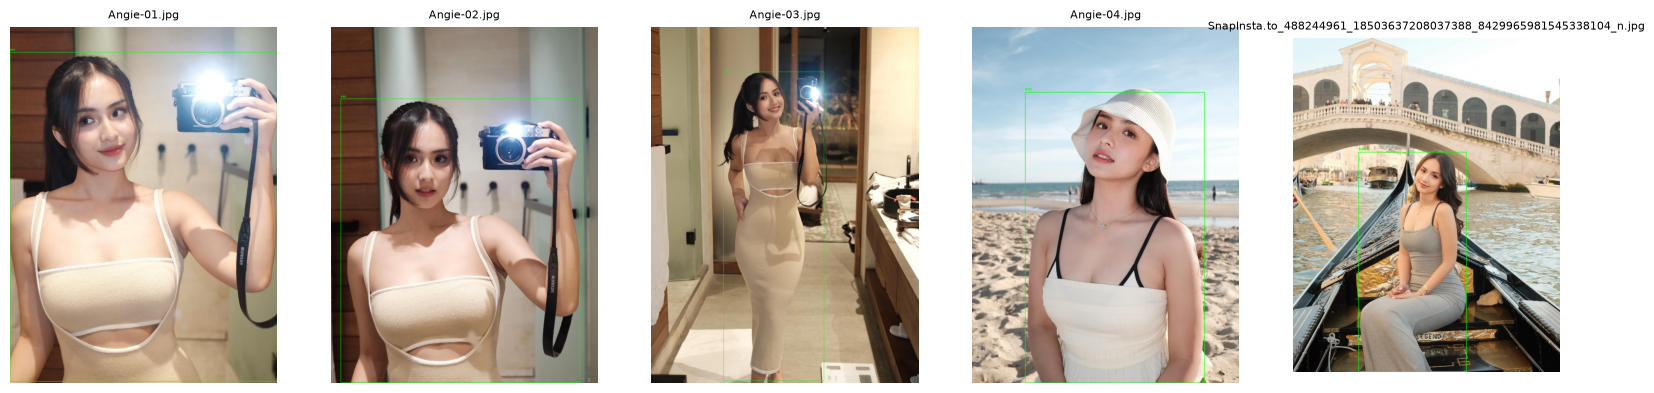

Angie-01.jpg: 1 box
(0, 174, 1829, 2426, 0.9148057699203491)
Angie-02.jpg: 1 box
(69, 493, 1703, 2433, 0.8136014938354492)
Angie-03.jpg: 1 box
(691, 432, 1653, 3392, 0.8788920640945435)
Angie-04.jpg: 1 box
(286, 353, 1253, 1919, 0.9144283533096313)
SnapInsta.to_488244961_18503637208037388_8429965981545338104_n.jpg: 1 box
(355, 615, 935, 1797, 0.8883724808692932)


In [104]:
# Runner "define -> demonstrate": menjalankan detect_humans pada DISPLAY_LIMIT gambar
# pertama di data/raw/ dan menggambar box hasilnya. Butuh data/raw/<identitas>/ terisi
# foto sungguhan dan koneksi internet (untuk mengunduh bobot model saat pertama kali
# dijalankan) — sengaja tidak dieksekusi otomatis saat pemeriksaan kode (lihat
# README.md); Arya yang menjalankannya setelah mengisi data.
_runner_image_paths = list(
    islice(
        (
            image_path
            for identity_dir in sorted(RAW_DIR.iterdir())
            if identity_dir.is_dir()
            for image_path in sorted(identity_dir.iterdir())
            if image_path.suffix.lower() in IMAGE_EXTENSIONS
        ),
        DISPLAY_LIMIT,
    )
)

_runner_model = load_detector(MODEL_WEIGHTS)
_runner_images = [cv2.imread(str(path)) for path in _runner_image_paths]
_runner_boxes = [
    detect_humans(_runner_model, path, CONF_THRESHOLD) for path in _runner_image_paths
]

_runner_figure, _runner_axes = plt.subplots(
    1, len(_runner_image_paths), figsize=(4 * len(_runner_image_paths), 6), squeeze=False
)
for _runner_axis, _runner_path, _runner_image, _runner_image_boxes in zip(
    _runner_axes[0], _runner_image_paths, _runner_images, _runner_boxes
):
    _runner_display = _runner_image.copy()
    for _runner_box in _runner_image_boxes[:DISPLAY_LIMIT]:
        cv2.rectangle(
            _runner_display,
            (_runner_box.x1, _runner_box.y1),
            (_runner_box.x2, _runner_box.y2),
            (0, 255, 0),
            2,
        )
        cv2.putText(
            _runner_display,
            f"{_runner_box.confidence:.2f}",
            (_runner_box.x1, max(_runner_box.y1 - 10, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
        )
    _runner_axis.imshow(cv2.cvtColor(_runner_display, cv2.COLOR_BGR2RGB))
    _runner_axis.set_title(_runner_path.name, fontsize=8)
    _runner_axis.axis("off")
plt.show()

for _runner_path, _runner_image_boxes in zip(_runner_image_paths, _runner_boxes):
    print(f"{_runner_path.name}: {len(_runner_image_boxes)} box")
    for _runner_box in _runner_image_boxes[:DISPLAY_LIMIT]:
        print((_runner_box.x1, _runner_box.y1, _runner_box.x2, _runner_box.y2, _runner_box.confidence))

## 5. Validasi jumlah deteksi (K2)


In [105]:
def validate_single_detection(boxes: list[BoundingBox]) -> BoundingBox:
    """Memilih box "person" dengan confidence tertinggi pada satu gambar.

    Args:
        boxes: Daftar box hasil `detect_humans`.

    Returns:
        Box dengan confidence tertinggi.

    Raises:
        NoDetectionError: Kalau tidak ada box sama sekali.
    """
    if len(boxes) == 0:
        raise NoDetectionError('Tidak ada box "person" terdeteksi')
    return max(boxes, key=lambda box: box.confidence)


In [106]:
# Runner "define -> demonstrate": memvalidasi hasil runner deteksi di atas per gambar
# dengan memilih box confidence tertinggi. Bergantung pada
# _runner_image_paths/_runner_images/_runner_boxes — sengaja tidak dieksekusi otomatis
# saat pemeriksaan kode (lihat README.md).
_runner_validated = []
for _runner_path, _runner_image, _runner_image_boxes in zip(
    _runner_image_paths, _runner_images, _runner_boxes
):
    try:
        _runner_box = validate_single_detection(_runner_image_boxes)
    except NoDetectionError as e:
        print(f"{_runner_path.name}: dilewati, {e}")
        continue
    print(
        f"{_runner_path.name}: lolos, "
        f"{(_runner_box.x1, _runner_box.y1, _runner_box.x2, _runner_box.y2, _runner_box.confidence)}"
    )
    _runner_validated.append((_runner_path, _runner_image, _runner_box))

Angie-01.jpg: lolos, (0, 174, 1829, 2426, 0.9148057699203491)
Angie-02.jpg: lolos, (69, 493, 1703, 2433, 0.8136014938354492)
Angie-03.jpg: lolos, (691, 432, 1653, 3392, 0.8788920640945435)
Angie-04.jpg: lolos, (286, 353, 1253, 1919, 0.9144283533096313)
SnapInsta.to_488244961_18503637208037388_8429965981545338104_n.jpg: lolos, (355, 615, 935, 1797, 0.8883724808692932)


## 6. Cropping (K3, K4, K5)


In [107]:
def _apply_padding(
    box: BoundingBox, image_shape: tuple[int, int], padding_ratio: float
) -> tuple[int, int, int, int]:
    height, width = image_shape
    box_width = box.x2 - box.x1
    box_height = box.y2 - box.y1
    pad_x = int(box_width * padding_ratio)
    pad_y = int(box_height * padding_ratio)

    x1 = max(box.x1 - pad_x, 0)
    y1 = max(box.y1 - pad_y, 0)
    x2 = min(box.x2 + pad_x, width)
    y2 = min(box.y2 + pad_y, height)
    return x1, y1, x2, y2


def _is_large_enough(region: np.ndarray, min_side_px: int) -> bool:
    height, width = region.shape[:2]
    return max(height, width) >= min_side_px


def crop_with_padding(
    image: np.ndarray, box: BoundingBox, padding_ratio: float, min_side_px: int
) -> np.ndarray:
    """Memotong region sesuai box dengan padding, menolak hasil yang terlalu kecil.

    Args:
        image: Gambar asal, hasil `cv2.imread`.
        box: Box "person" yang sudah divalidasi tepat satu.
        padding_ratio: Rasio padding simetris di semua sisi box.
        min_side_px: Sisi terpanjang minimum hasil crop yang masih diterima.

    Returns:
        Region gambar hasil crop.

    Raises:
        CropTooSmallError: Kalau sisi terpanjang hasil crop di bawah `min_side_px`.
    """
    x1, y1, x2, y2 = _apply_padding(box, image.shape[:2], padding_ratio)
    region = image[y1:y2, x1:x2]
    if not _is_large_enough(region, min_side_px):
        raise CropTooSmallError(
            f"Crop {max(region.shape[:2])}px di bawah ambang {min_side_px}px"
        )
    return region


def save_crop(region: np.ndarray, output_path: Path) -> None:
    """Menyimpan hasil crop ke berkas.

    Args:
        region: Region hasil `crop_with_padding`.
        output_path: Path tujuan penyimpanan.

    Raises:
        CropSaveError: Kalau berkas gagal ditulis.
    """
    try:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        ok = cv2.imwrite(str(output_path), region)
    except OSError as e:
        logger.error(f"Crop gagal disimpan ke {output_path}: {e}", exc_info=True)
        raise CropSaveError(f"Crop gagal disimpan ke {output_path}: {e}") from e
    if not ok:
        raise CropSaveError(f"Crop gagal disimpan ke {output_path}")


def build_crop_filename(source_path: Path) -> str:
    """Membentuk nama file hasil crop dari nama file asal, agar re-run menimpa (K5).

    Args:
        source_path: Path gambar asal.

    Returns:
        Nama file hasil crop, mis. "foto1_person.jpg".
    """
    return f"{source_path.stem}_person.jpg"


Angie-01_person.jpg: 1829x2438px
Angie-02_person.jpg: 1827x2331px
Angie-03_person.jpg: 1346x3413px
Angie-04_person.jpg: 1347x1880px
SnapInsta.to_488244961_18503637208037388_8429965981545338104_n_person.jpg: 812x1420px


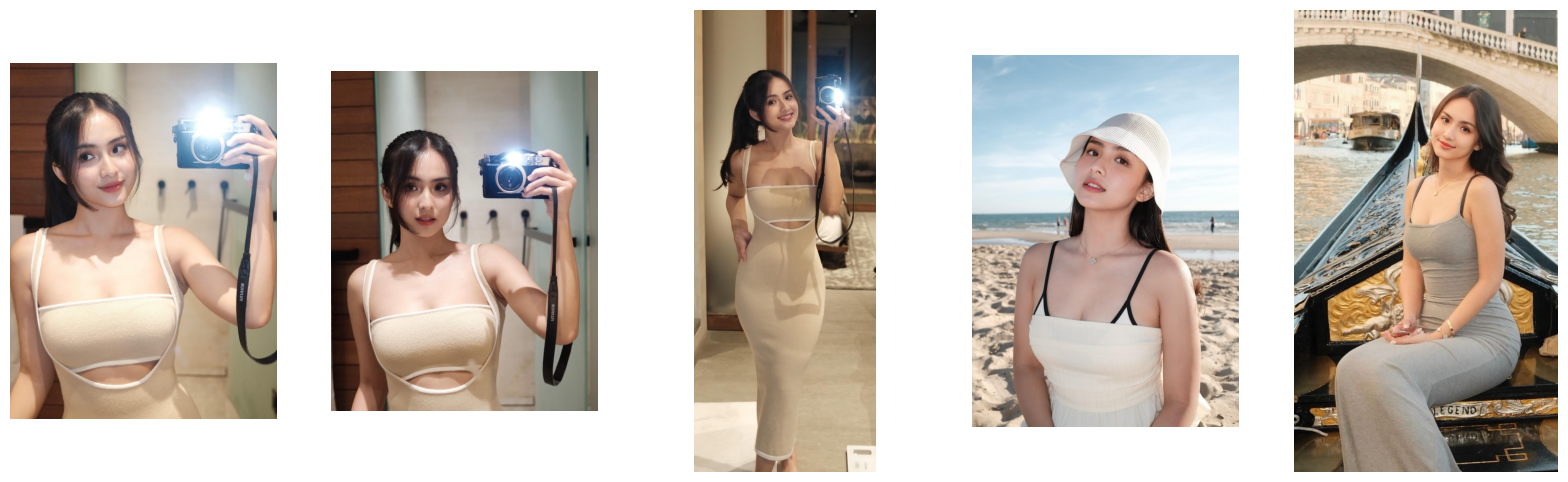

In [108]:
# Runner "define -> demonstrate": menerapkan crop_with_padding pada gambar yang lolos
# validasi di runner sebelumnya, lalu menampilkan hasil crop-nya. Bergantung pada
# _runner_validated — sengaja tidak dieksekusi otomatis saat pemeriksaan kode (lihat
# README.md).
_runner_crops = []
for _runner_path, _runner_image, _runner_box in _runner_validated:
    try:
        _runner_region = crop_with_padding(_runner_image, _runner_box, PADDING_RATIO, MIN_SIDE_PX)
    except CropTooSmallError as e:
        print(f"{_runner_path.name}: dilewati, {e}")
        continue
    print(
        f"{build_crop_filename(_runner_path)}: "
        f"{_runner_region.shape[1]}x{_runner_region.shape[0]}px"
    )
    _runner_crops.append(_runner_region)

if _runner_crops:
    _runner_figure, _runner_axes = plt.subplots(
        1, len(_runner_crops), figsize=(4 * len(_runner_crops), 6), squeeze=False
    )
    for _runner_axis, _runner_region in zip(_runner_axes[0], _runner_crops):
        _runner_axis.imshow(cv2.cvtColor(_runner_region, cv2.COLOR_BGR2RGB))
        _runner_axis.axis("off")
    plt.show()

## 7. Orkestrasi per identitas


In [109]:
class ProcessOutcome(Enum):
    """Kategori hasil pemrosesan satu gambar."""

    CROPPED = "cropped"
    SKIPPED_NO_DETECTION = "skipped_no_detection"
    SKIPPED_TOO_SMALL = "skipped_too_small"
    SKIPPED_UNREADABLE = "skipped_unreadable"


@dataclass
class ProcessSummary:
    """Ringkasan hasil pemrosesan satu identitas."""

    cropped: int = 0
    skipped_no_detection: int = 0
    skipped_too_small: int = 0
    skipped_unreadable: int = 0


def total_skipped(summary: ProcessSummary) -> int:
    """Menghitung total gambar yang dilewati pada satu ringkasan.

    Args:
        summary: Ringkasan hasil `process_identity`.

    Returns:
        Jumlah gambar yang dilewati dari semua kategori.
    """
    return summary.skipped_no_detection + summary.skipped_too_small + summary.skipped_unreadable


def _read_image(image_path: Path) -> np.ndarray:
    try:
        image = cv2.imread(str(image_path))
    except cv2.error as e:
        logger.error(f"Gambar tidak bisa dibaca: {image_path}: {e}", exc_info=True)
        raise ImageReadError(f"Gambar tidak bisa dibaca: {image_path}") from e
    if image is None:
        raise ImageReadError(f"Gambar tidak bisa dibaca (format tidak dikenali): {image_path}")
    return image


def _list_images(identity_dir: Path) -> list[Path]:
    return sorted(p for p in identity_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)


def _process_image(
    image_path: Path,
    output_dir: Path,
    model: YOLO,
    conf_threshold: float,
    padding_ratio: float,
    min_side_px: int,
) -> ProcessOutcome:
    try:
        image = _read_image(image_path)
    except ImageReadError as e:
        logger.warning(str(e))
        return ProcessOutcome.SKIPPED_UNREADABLE

    boxes = detect_humans(model, image_path, conf_threshold)
    try:
        box = validate_single_detection(boxes)
    except NoDetectionError:
        logger.info(f'Dilewati, tidak ada deteksi "person": {image_path}')
        return ProcessOutcome.SKIPPED_NO_DETECTION

    try:
        region = crop_with_padding(image, box, padding_ratio, min_side_px)
    except CropTooSmallError as e:
        logger.warning(f"Dilewati, {e}: {image_path}")
        return ProcessOutcome.SKIPPED_TOO_SMALL

    output_path = output_dir / build_crop_filename(image_path)
    save_crop(region, output_path)
    return ProcessOutcome.CROPPED


def process_identity(
    identity_dir: Path,
    output_dir: Path,
    model: YOLO,
    conf_threshold: float,
    padding_ratio: float,
    min_side_px: int,
) -> ProcessSummary:
    """Menjalankan deteksi, pemilihan box, dan cropping untuk satu identitas."""
    if not identity_dir.exists():
        logger.warning(f"Folder identitas tidak ditemukan: {identity_dir}")
        return ProcessSummary()

    output_dir.mkdir(parents=True, exist_ok=True)
    summary = ProcessSummary()
    for image_path in _list_images(identity_dir):
        outcome = _process_image(
            image_path, output_dir, model, conf_threshold, padding_ratio, min_side_px
        )
        setattr(summary, outcome.value, getattr(summary, outcome.value) + 1)

    logger.info(
        f"[{identity_dir.name}] {summary.cropped} crop tersimpan di {output_dir}, "
        f"{total_skipped(summary)} dilewati"
    )
    return summary


def run_pipeline(identities: dict[str, Path]) -> dict[str, ProcessSummary]:
    """Menjalankan pipeline untuk setiap identitas.

    Args:
        identities: Pemetaan nama identitas ke folder `data/raw/<identitas>`.

    Returns:
        Ringkasan hasil pemrosesan per identitas.
    """
    model = load_detector(MODEL_WEIGHTS)

    summaries: dict[str, ProcessSummary] = {}
    for identity_name, identity_dir in identities.items():
        output_dir = CROPPED_DIR / identity_name
        summaries[identity_name] = process_identity(
            identity_dir,
            output_dir,
            model,
            CONF_THRESHOLD,
            PADDING_RATIO,
            MIN_SIDE_PX,
        )
    return summaries

In [110]:
# Runner "define -> demonstrate": menjalankan pipeline untuk semua folder di data/raw/
# dan menampilkan ringkasan DISPLAY_LIMIT identitas pertama. Isi data/raw/<identitas>/
# dengan foto identitas sebelum menjalankan sel ini. Sel ini mengunduh bobot yolov8n.pt
# (butuh koneksi internet sekali) dan memanggil model sungguhan — sengaja tidak
# dijalankan otomatis saat pemeriksaan kode (lihat README.md).
IDENTITIES = {
    identity_dir.name: identity_dir
    for identity_dir in sorted(RAW_DIR.iterdir())
    if identity_dir.is_dir()
} if RAW_DIR.exists() else {}

summaries = run_pipeline(IDENTITIES)
for identity_name, summary in islice(summaries.items(), DISPLAY_LIMIT):
    print(f"{identity_name}: {summary.cropped} crop, {total_skipped(summary)} dilewati")

2026-09-28 04:23:13,361 | INFO     | human_detection_and_cropping | [angie] 47 crop tersimpan di c:\Project\identity-lora-pipeline\data\cropped\angie, 0 dilewati
angie: 47 crop, 0 dilewati
